In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import cohen_kappa_score, f1_score, accuracy_score
from tqdm import tqdm
import os


AR_CSV = r"D:\TP_RES_NEUR\Crop-Classification-Project\data\sentinel2\arkansas.csv"
CA_CSV = r"D:\TP_RES_NEUR\Crop-Classification-Project\data\sentinel2\california.csv"

# ── Label remapping — CDL codes → 0-based class indices ──
# Arkansas (paper Table 2 order)
AR_REMAP = {5: 0, 3: 1, 1: 2, 2: 3, 0: 4}
AR_CLASSES = ['Soybeans', 'Rice', 'Corn', 'Cotton', 'Others']

# California (paper Table 2 order)
# teammate used code 69 for grapes
CA_REMAP = {69: 0, 3: 1, 36: 2, 75: 3, 204: 4, 0: 5}
CA_CLASSES = ['Grapes', 'Rice', 'Alfalfa', 'Almonds', 'Pistachios', 'Others']


def load_teammate_data(csv_path, label_remap, class_names):
    """
    Load data in teammate's format:
    CSV columns: B2_0..B12_35, SCL_0..SCL_35,
                 crop_0..crop_35, mask_0..mask_35, target_label
    Returns X [N,36,10], mask [N,36], labels [N]
    """
    print(f"Loading {csv_path}...")
    df = pd.read_csv(csv_path)
    print(f"  Shape: {df.shape}")

    # ── Reshape to (N, 36, 13) ──
    y_raw    = df['target_label'].values
    features = df.drop(columns=['target_label']).values
    data_3d  = features.reshape(-1, 36, 13)  # (N, 36, 13)

    # ── Extract X (10 spectral bands) and mask ──
    X    = data_3d[:, :, :10].astype(np.float32)   # [N, 36, 10]
    mask = data_3d[:, :, 12].astype(np.float32)    # [N, 36]

    # ── Normalize reflectance (divide by 10000 if not already done) ──
    # Check if values are in raw DN range (>10) or already normalized
    if X.max() > 10:
        X = X / 10000.0
        print("  Normalized reflectance values by /10000")

    # ── Remap labels ──
    n_classes = len(class_names)
    labels = np.array([label_remap.get(int(l), n_classes-1) for l in y_raw])

    print(f"  X shape:    {X.shape}")
    print(f"  Mask shape: {mask.shape}")
    print(f"  Class distribution:")
    for i, name in enumerate(class_names):
        count = (labels == i).sum()
        pct   = count / len(labels) * 100
        print(f"    {i}: {name:12s} → {count:5,} ({pct:.1f}%)")

    return X, mask, labels


# Load both states
X_ar, mask_ar, y_ar = load_teammate_data(AR_CSV, AR_REMAP, AR_CLASSES)
print()
X_ca, mask_ca, y_ca = load_teammate_data(CA_CSV, CA_REMAP, CA_CLASSES)

Loading D:\TP_RES_NEUR\Crop-Classification-Project\data\sentinel2\arkansas.csv...
  Shape: (10000, 469)
  Normalized reflectance values by /10000
  X shape:    (10000, 36, 10)
  Mask shape: (10000, 36)
  Class distribution:
    0: Soybeans     → 4,677 (46.8%)
    1: Rice         → 2,423 (24.2%)
    2: Corn         → 1,522 (15.2%)
    3: Cotton       →   762 (7.6%)
    4: Others       →   616 (6.2%)

Loading D:\TP_RES_NEUR\Crop-Classification-Project\data\sentinel2\california.csv...
  Shape: (10000, 469)
  Normalized reflectance values by /10000
  X shape:    (10000, 36, 10)
  Mask shape: (10000, 36)
  Class distribution:
    0: Grapes       → 2,054 (20.5%)
    1: Rice         → 2,037 (20.4%)
    2: Alfalfa      →   974 (9.7%)
    3: Almonds      →   783 (7.8%)
    4: Pistachios   →   640 (6.4%)
    5: Others       → 3,512 (35.1%)


In [2]:
def split_paper(X, mask, labels, n_classes,
                n_train=240, n_val=60, seed=42):
    """
    Paper section 2.4:
    300 samples per class → 240 train + 60 val, rest = test
    """
    rng = np.random.RandomState(seed)
    train_idx, val_idx, test_idx = [], [], []

    for c in range(n_classes):
        idx = np.where(labels == c)[0]
        rng.shuffle(idx)

        if len(idx) >= n_train + n_val:
            train_idx.extend(idx[:n_train])
            val_idx.extend(idx[n_train:n_train + n_val])
            test_idx.extend(idx[n_train + n_val:])
        elif len(idx) >= n_train:
            train_idx.extend(idx[:n_train])
            val_idx.extend(idx[n_train:])
        else:
            train_idx.extend(idx)

    return np.array(train_idx), np.array(val_idx), np.array(test_idx)


# Split Arkansas
tr_ar, val_ar, te_ar = split_paper(X_ar, mask_ar, y_ar, 5)
print("Arkansas split:")
print(f"  Train: {len(tr_ar)} | Val: {len(val_ar)} | Test: {len(te_ar)}")

# Split California
tr_ca, val_ca, te_ca = split_paper(X_ca, mask_ca, y_ca, 6)
print("California split:")
print(f"  Train: {len(tr_ca)} | Val: {len(val_ca)} | Test: {len(te_ca)}")

Arkansas split:
  Train: 1200 | Val: 300 | Test: 8500
California split:
  Train: 1440 | Val: 360 | Test: 8200


CELL 3

In [ ]:
import math
import torch
import torch.nn as nn

# ─────────────────────────────────────────────────────
# ECA — Efficient Channel Attention (Figure 5)
# ─────────────────────────────────────────────────────
class ECA(nn.Module):
    def __init__(self, kernel_size=3):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool1d(1)
        self.conv     = nn.Conv1d(1, 1, kernel_size=kernel_size,
                                  padding=kernel_size//2, bias=False)
        self.sigmoid  = nn.Sigmoid()

    def forward(self, x):
        # x: [B, T, C]
        y = x.transpose(1, 2)    # [B, C, T]
        y = self.avg_pool(y)     # [B, C, 1]
        y = y.transpose(1, 2)   # [B, 1, C]
        y = self.conv(y)         # [B, 1, C]
        y = self.sigmoid(y)      # [B, 1, C]
        return x * y             # [B, T, C]


# ─────────────────────────────────────────────────────
# ALPE — Attention-based Learnable Positional Encoding
# Paper equation 3: ALPE(t) = ECA(Conv1D(PE(t) × mask))
# Figure 5: PE → mask → 1D Conv → AvgPool+1D Conv (ECA) → ⊗
# ─────────────────────────────────────────────────────
class ALPE(nn.Module):
    def __init__(self, seq_len, d_model):
        super().__init__()
        self.conv1d = nn.Conv1d(d_model, d_model,
                                kernel_size=3, padding=1, bias=False)
        self.eca    = ECA(kernel_size=3)

        # Fixed sinusoidal positional encoding (equation 2)
        pe       = torch.zeros(seq_len, d_model)
        position = torch.arange(seq_len).float().unsqueeze(1)
        div_term = torch.exp(
            torch.arange(0, d_model, 2).float()
            * (-math.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term[:pe[:, 1::2].shape[1]])
        self.register_buffer('pe', pe)  # [T, d_model]

    def forward(self, x, mask):
        """
        x:    [B, T, d_model]
        mask: [B, T]  — 1=valid, 0=missing (Input 2 in paper)
        """
        B = x.shape[0]
        # Step 1: absolute PE → 2D vector
        pe       = self.pe.unsqueeze(0).expand(B, -1, -1)  # [B, T, d_model]
        # Step 2: mask missing positions
        mask_exp = mask.unsqueeze(-1).float()               # [B, T, 1]
        pe_masked = pe * mask_exp                           # [B, T, d_model]
        # Step 3: 1D Conv
        pe_conv = self.conv1d(
            pe_masked.transpose(1, 2)
        ).transpose(1, 2)                                   # [B, T, d_model]
        # Step 4: ECA (Average Pooling + 1D Conv)
        pe_out = self.eca(pe_conv)                          # [B, T, d_model]
        # Step 5: add to input
        return x + pe_out


# ─────────────────────────────────────────────────────
# Transformer Sub-module (Figure 4)
# ─────────────────────────────────────────────────────
class TransformerSubModule(nn.Module):
    def __init__(self, d_model, n_head,
                 use_alpe=False, seq_len=None, dropout=0.1):
        super().__init__()
        self.use_alpe = use_alpe
        if use_alpe:
            self.alpe = ALPE(seq_len, d_model)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_head,
            dim_feedforward=d_model * 4,
            dropout=dropout,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(
            encoder_layer, num_layers=1
        )

    def forward(self, x, mask=None):
        if self.use_alpe and mask is not None:
            x = self.alpe(x, mask)
        return self.transformer(x)


# ─────────────────────────────────────────────────────
# CNN Sub-module (Figure 6)
# Two 1D convs + BN + ReLU + residual skip
# ─────────────────────────────────────────────────────
class CNNSubModule(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size=3):
        super().__init__()
        pad        = kernel_size // 2
        self.conv1 = nn.Conv1d(in_ch,  out_ch, kernel_size,
                               padding=pad, bias=False)
        self.bn1   = nn.BatchNorm1d(out_ch)
        self.conv2 = nn.Conv1d(out_ch, out_ch, kernel_size,
                               padding=pad, bias=False)
        self.bn2   = nn.BatchNorm1d(out_ch)
        self.relu  = nn.ReLU()
        self.skip  = (nn.Conv1d(in_ch, out_ch, 1, bias=False)
                      if in_ch != out_ch else nn.Identity())

    def forward(self, x):
        # x: [B, T, in_ch]
        x        = x.transpose(1, 2)        # [B, in_ch, T]
        residual = self.skip(x)
        out      = self.relu(self.bn1(self.conv1(x)))
        out      = self.bn2(self.conv2(out))
        out      = self.relu(out + residual)
        return out.transpose(1, 2)          # [B, T, out_ch]


# ─────────────────────────────────────────────────────
# CTFusion Module (Figure 3)
# CNN || Transformer → Concat → MaxPool
# ─────────────────────────────────────────────────────
class CTFusion(nn.Module):
    def __init__(self, in_ch, out_ch, n_head,
                 kernel_size=3, use_alpe=False, seq_len=None):
        super().__init__()
        self.cnn         = CNNSubModule(in_ch, out_ch, kernel_size)
        self.transformer = TransformerSubModule(
            in_ch, n_head,
            use_alpe=use_alpe, seq_len=seq_len
        )
        # Concat: CNN output (out_ch) + Transformer output (in_ch)
        self.proj = nn.Linear(out_ch + in_ch, out_ch)
        self.pool = nn.MaxPool1d(kernel_size=2, stride=2)

    def forward(self, x, mask=None):
        cnn_out   = self.cnn(x)                              # [B, T, out_ch]
        trans_out = self.transformer(x, mask)                # [B, T, in_ch]
        fused     = torch.cat([cnn_out, trans_out], dim=-1)  # [B, T, out+in]
        fused     = self.proj(fused)                         # [B, T, out_ch]
        fused     = self.pool(
            fused.transpose(1, 2)
        ).transpose(1, 2)                                    # [B, T/2, out_ch]
        return fused


# ─────────────────────────────────────────────────────
# MCTNet — Full architecture (Figure 3)
#
# Exact dimensions from Figure 3:
#   Input:   10 × 36
#   Stage 1: 20 × 18  (channels: 10→20, time: 36→18)
#   Stage 2: 40 × 9   (channels: 20→40, time: 18→9)
#   Stage 3: 80 × 4   (channels: 40→80, time: 9→4)
#   Global Max Pool → 80 × 1
#   MLP → N classes
# ─────────────────────────────────────────────────────
class MCTNet(nn.Module):
    def __init__(self, in_channels=10, seq_len=36,
                 n_classes=5, n_stage=3, n_head=5,
                 kernel_size=3):
        super().__init__()

        # Exact channel progression from Figure 3
        dims = [in_channels] + [in_channels * (2**i) 
                                for i in range(1, n_stage + 1)]
        # dims = [10, 20, 40, 80]

        self.stages = nn.ModuleList()
        cur_seq = seq_len

        for i in range(n_stage):
            in_ch  = dims[i]
            out_ch = dims[i + 1]
            
            # FIXED: always use n_head=5 everywhere (10 is divisible by 5)
            self.stages.append(
                CTFusion(
                    in_ch=in_ch, 
                    out_ch=out_ch, 
                    n_head=n_head,           # ← 5 heads for all stages
                    kernel_size=kernel_size,
                    use_alpe=(i == 0),       # ALPE only in first stage
                    seq_len=cur_seq
                )
            )
            cur_seq = cur_seq // 2

        # Global max pooling → MLP classifier
        final_ch = dims[-1]  # 80
        self.classifier = nn.Linear(final_ch, n_classes)

    def forward(self, x, mask=None):
        for i, stage in enumerate(self.stages):
            m = mask if i == 0 else None
            x = stage(x, m)

        # Global max pooling over time dimension (paper Figure 3)
        x = x.max(dim=1).values    # [B, final_ch]
        return self.classifier(x)  # [B, n_classes]

model_ar = MCTNet(in_channels=10, seq_len=36, n_classes=5,
                  n_stage=3, n_head=5, kernel_size=3)
model_ca = MCTNet(in_channels=10, seq_len=36, n_classes=6,
                  n_stage=3, n_head=5, kernel_size=3)

x    = torch.randn(4, 36, 10)
mask = torch.ones(4, 36)
mask[:, [2, 10, 25]] = 0

# Trace intermediate shapes
print("\nIntermediate shapes (should match Figure 3):")
with torch.no_grad():
    feat = x.clone()
    for i, stage in enumerate(model_ar.stages):
        m    = mask if i == 0 else None
        feat = stage(feat, m)
        print(f"  After Stage {i+1}: {feat.shape}  "
              f"(expect [4, {36//(2**(i+1))}, {10*(2**(i+1))}])")

out_ar = model_ar(x, mask)
out_ca = model_ca(x, mask)
print(f"\nFinal output Arkansas:   {out_ar.shape}  (expect [4, 5])")
print(f"Final output California: {out_ca.shape}  (expect [4, 6])")
print(f"\nParameters Arkansas:   {sum(p.numel() for p in model_ar.parameters()):,}")
print(f"Parameters California: {sum(p.numel() for p in model_ca.parameters()):,}")

print("\nMCTNet architecture verified!")

Verifying MCTNet shapes match Figure 3...

Intermediate shapes (should match Figure 3):
  After Stage 1: torch.Size([4, 18, 20])  (expect [4, 18, 20])
  After Stage 2: torch.Size([4, 9, 40])  (expect [4, 9, 40])
  After Stage 3: torch.Size([4, 4, 80])  (expect [4, 4, 80])

Final output Arkansas:   torch.Size([4, 5])  (expect [4, 5])
Final output California: torch.Size([4, 6])  (expect [4, 6])

Parameters Arkansas:   82,118
Parameters California: 82,199

MCTNet architecture verified!


C:\Users\USER\AppData\Local\Temp\ipykernel_25388\142304231.py:88: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.num_heads is odd
  self.transformer = nn.TransformerEncoder(


In [20]:
class CropDataset(Dataset):
    def __init__(self, X, mask, y):
        self.X    = torch.tensor(X,    dtype=torch.float32)
        self.mask = torch.tensor(mask, dtype=torch.float32)
        self.y    = torch.tensor(y,    dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.mask[idx], self.y[idx]


def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for X, mask, y in loader:
        X, mask, y = X.to(device), mask.to(device), y.to(device)
        optimizer.zero_grad()
        out  = model(X, mask)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(y)
        correct    += (out.argmax(1) == y).sum().item()
        total      += len(y)
    return total_loss / total, correct / total


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss               = 0
    all_preds, all_labels    = [], []
    with torch.no_grad():
        for X, mask, y in loader:
            X, mask, y = X.to(device), mask.to(device), y.to(device)
            out        = model(X, mask)
            loss       = criterion(out, y)
            total_loss += loss.item() * len(y)
            all_preds.extend(out.argmax(1).cpu().numpy())
            all_labels.extend(y.cpu().numpy())
    total = len(all_labels)
    oa    = accuracy_score(all_labels, all_preds)
    kappa = cohen_kappa_score(all_labels, all_preds)
    f1    = f1_score(all_labels, all_preds,
                     average='macro', zero_division=0)
    return total_loss / total, oa, kappa, f1


def train_mctnet(X, mask, labels, class_names,
                 train_idx, val_idx, test_idx,
                 state_name, save_dir,
                 epochs=200, batch_size=32,
                 lr=0.001, device='cpu'):
    """
    Full training pipeline — exact paper settings:
    batch=32, epochs=200, lr=0.001, Adam optimizer
    """
    n_classes = len(class_names)
    os.makedirs(save_dir, exist_ok=True)

    # Datasets
    train_ds = CropDataset(X[train_idx], mask[train_idx], labels[train_idx])
    val_ds   = CropDataset(X[val_idx],   mask[val_idx],   labels[val_idx])
    test_ds  = CropDataset(X[test_idx],  mask[test_idx],  labels[test_idx])

    train_loader = DataLoader(train_ds, batch_size=batch_size,
                              shuffle=True,  num_workers=0)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size,
                              shuffle=False, num_workers=0)
    test_loader  = DataLoader(test_ds,  batch_size=256,
                              shuffle=False, num_workers=0)

    # Model — paper hyperparameters Table 3
    model = MCTNet(
        in_channels=10, seq_len=36,
        n_classes=n_classes,
        n_stage=3, n_head=5,
        kernel_size=3,
    ).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    print(f"\n{'='*60}")
    print(f"Training MCTNet — {state_name}")
    print(f"  Device:  {device}")
    print(f"  Params:  {sum(p.numel() for p in model.parameters()):,}")
    print(f"  Train:   {len(train_idx)} | Val: {len(val_idx)} | Test: {len(test_idx)}")
    print(f"{'='*60}")

    best_kappa = -1
    best_state = None
    history    = []

    for epoch in range(1, epochs + 1):
        tr_loss, tr_oa = train_epoch(
            model, train_loader, optimizer, criterion, device)
        va_loss, va_oa, va_kappa, va_f1 = evaluate(
            model, val_loader, criterion, device)

        history.append({
            'epoch':      epoch,
            'train_loss': tr_loss, 'train_oa': tr_oa,
            'val_loss':   va_loss, 'val_oa':   va_oa,
            'val_kappa':  va_kappa,'val_f1':   va_f1
        })

        if va_kappa > best_kappa:
            best_kappa = va_kappa
            best_state = {k: v.clone()
                          for k, v in model.state_dict().items()}

        if epoch % 20 == 0:
            print(f"Epoch {epoch:3d}/{epochs} | "
                  f"Train OA: {tr_oa:.3f} | "
                  f"Val OA: {va_oa:.3f} "
                  f"Kappa: {va_kappa:.3f} "
                  f"F1: {va_f1:.3f}")

    # Restore best weights
    model.load_state_dict(best_state)

    # Final test evaluation
    _, te_oa, te_kappa, te_f1 = evaluate(
        model, test_loader, criterion, device)

    print(f"\n{'='*60}")
    print(f"{state_name} — FINAL TEST RESULTS")
    paper = {'Arkansas':   (0.968, 0.951, 0.933),
             'California': (0.852, 0.806, 0.829)}
    p = paper.get(state_name, (0, 0, 0))
    print(f"  OA:    {te_oa:.4f}  (paper: {p[0]})")
    print(f"  Kappa: {te_kappa:.4f}  (paper: {p[1]})")
    print(f"  F1:    {te_f1:.4f}  (paper: {p[2]})")
    print(f"{'='*60}")

    # Save model and history
    torch.save(model.state_dict(),
               os.path.join(save_dir, f'mctnet_{state_name.lower()}.pth'))
    hist_df = pd.DataFrame(history)
    hist_df.to_csv(
        os.path.join(save_dir, f'history_{state_name.lower()}.csv'),
        index=False)

    return model, hist_df, (te_oa, te_kappa, te_f1)


device   = 'cuda' if torch.cuda.is_available() else 'cpu'
SAVE_DIR = r"D:\TP_RES_NEUR\Crop-Classification-Project\models"
print(f"Device: {device}")
print("All functions ready!")

Device: cpu
All functions ready!


In [21]:
model_ar, hist_ar, results_ar = train_mctnet(
    X_ar, mask_ar, y_ar, AR_CLASSES,
    tr_ar, val_ar, te_ar,
    state_name='Arkansas',
    save_dir=SAVE_DIR,
    epochs=200, batch_size=32, lr=0.001,
    device=device
)

C:\Users\USER\AppData\Local\Temp\ipykernel_25388\142304231.py:88: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.num_heads is odd
  self.transformer = nn.TransformerEncoder(



Training MCTNet — Arkansas
  Device:  cpu
  Params:  82,118
  Train:   1200 | Val: 300 | Test: 8500
Epoch  20/200 | Train OA: 0.989 | Val OA: 0.930 Kappa: 0.912 F1: 0.929
Epoch  40/200 | Train OA: 0.991 | Val OA: 0.910 Kappa: 0.887 F1: 0.912
Epoch  60/200 | Train OA: 0.999 | Val OA: 0.937 Kappa: 0.921 F1: 0.937
Epoch  80/200 | Train OA: 1.000 | Val OA: 0.933 Kappa: 0.917 F1: 0.933
Epoch 100/200 | Train OA: 1.000 | Val OA: 0.940 Kappa: 0.925 F1: 0.940
Epoch 120/200 | Train OA: 0.993 | Val OA: 0.933 Kappa: 0.917 F1: 0.934
Epoch 140/200 | Train OA: 0.996 | Val OA: 0.943 Kappa: 0.929 F1: 0.943
Epoch 160/200 | Train OA: 1.000 | Val OA: 0.933 Kappa: 0.917 F1: 0.933
Epoch 180/200 | Train OA: 0.997 | Val OA: 0.920 Kappa: 0.900 F1: 0.919
Epoch 200/200 | Train OA: 1.000 | Val OA: 0.933 Kappa: 0.917 F1: 0.933

Arkansas — FINAL TEST RESULTS
  OA:    0.9252  (paper: 0.968)
  Kappa: 0.8865  (paper: 0.951)
  F1:    0.9149  (paper: 0.933)


In [22]:
model_ca, hist_ca, results_ca = train_mctnet(
    X_ca, mask_ca, y_ca, CA_CLASSES,
    tr_ca, val_ca, te_ca,
    state_name='California',
    save_dir=SAVE_DIR,
    epochs=200, batch_size=32, lr=0.001,
    device=device
)

C:\Users\USER\AppData\Local\Temp\ipykernel_25388\142304231.py:88: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.num_heads is odd
  self.transformer = nn.TransformerEncoder(



Training MCTNet — California
  Device:  cpu
  Params:  82,199
  Train:   1440 | Val: 360 | Test: 8200
Epoch  20/200 | Train OA: 0.999 | Val OA: 0.928 Kappa: 0.913 F1: 0.928
Epoch  40/200 | Train OA: 0.999 | Val OA: 0.944 Kappa: 0.933 F1: 0.944
Epoch  60/200 | Train OA: 1.000 | Val OA: 0.942 Kappa: 0.930 F1: 0.942
Epoch  80/200 | Train OA: 1.000 | Val OA: 0.944 Kappa: 0.933 F1: 0.945
Epoch 100/200 | Train OA: 1.000 | Val OA: 0.944 Kappa: 0.933 F1: 0.945
Epoch 120/200 | Train OA: 1.000 | Val OA: 0.944 Kappa: 0.933 F1: 0.945
Epoch 140/200 | Train OA: 1.000 | Val OA: 0.944 Kappa: 0.933 F1: 0.945
Epoch 160/200 | Train OA: 1.000 | Val OA: 0.944 Kappa: 0.933 F1: 0.944
Epoch 180/200 | Train OA: 1.000 | Val OA: 0.942 Kappa: 0.930 F1: 0.942
Epoch 200/200 | Train OA: 0.972 | Val OA: 0.922 Kappa: 0.907 F1: 0.922

California — FINAL TEST RESULTS
  OA:    0.9524  (paper: 0.852)
  Kappa: 0.9363  (paper: 0.806)
  F1:    0.9209  (paper: 0.829)


Cell A — confusion matrices

Generating Arkansas confusion matrix...


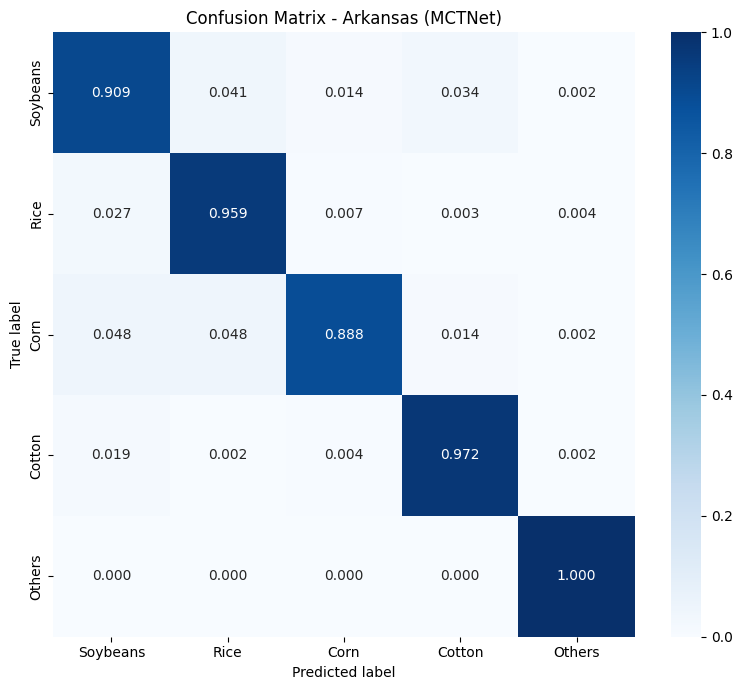

Generating California confusion matrix...


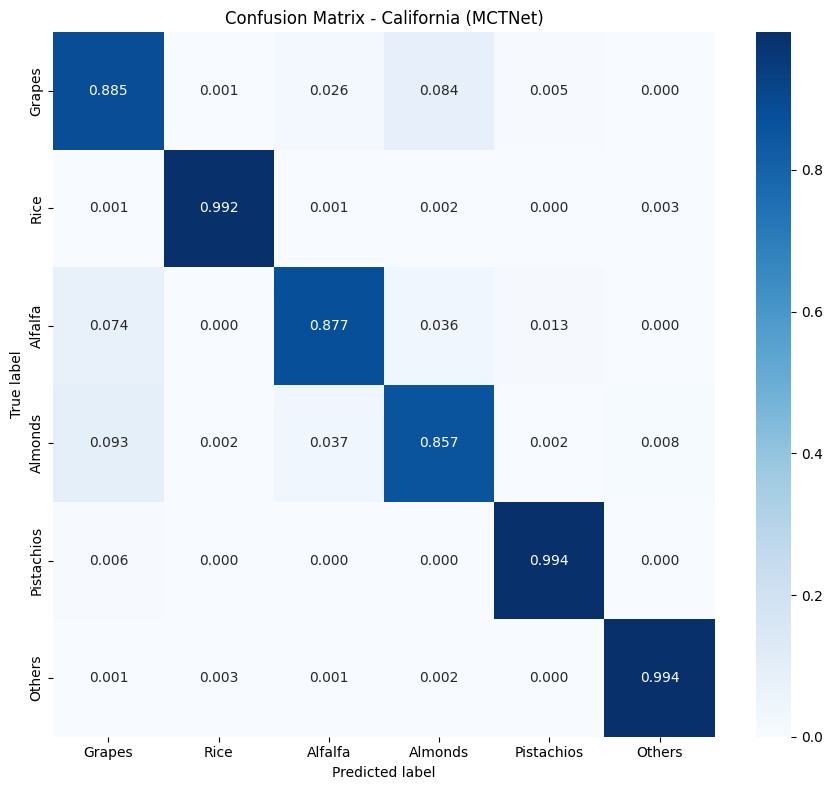

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import torch
from torch.utils.data import DataLoader

# ====================== ARKANSAS ======================
print("Generating Arkansas confusion matrix...")

# Use the existing Arkansas data + model
test_ds_ar = CropDataset(X_ar[te_ar], mask_ar[te_ar], y_ar[te_ar])
test_loader_ar = DataLoader(test_ds_ar, batch_size=256, shuffle=False, num_workers=0)

model_ar.eval()
all_preds_ar, all_labels_ar = [], []

with torch.no_grad():
    for X, mask, y in test_loader_ar:
        X, mask, y = X.to(device), mask.to(device), y.to(device)
        out = model_ar(X, mask)
        all_preds_ar.extend(out.argmax(1).cpu().numpy())
        all_labels_ar.extend(y.cpu().numpy())

cm_ar = confusion_matrix(all_labels_ar, all_preds_ar, normalize='true')

ar_classes = ['Soybeans', 'Rice', 'Corn', 'Cotton', 'Others']

plt.figure(figsize=(8, 7))
sns.heatmap(cm_ar, annot=True, fmt='.3f', cmap='Blues', 
            xticklabels=ar_classes, yticklabels=ar_classes, cbar=True)
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('Confusion Matrix - Arkansas (MCTNet)')
plt.tight_layout()
plt.show()

# ====================== CALIFORNIA ======================
print("Generating California confusion matrix...")

test_ds_ca = CropDataset(X_ca[te_ca], mask_ca[te_ca], y_ca[te_ca])
test_loader_ca = DataLoader(test_ds_ca, batch_size=256, shuffle=False, num_workers=0)

model_ca.eval()
all_preds_ca, all_labels_ca = [], []

with torch.no_grad():
    for X, mask, y in test_loader_ca:
        X, mask, y = X.to(device), mask.to(device), y.to(device)
        out = model_ca(X, mask)
        all_preds_ca.extend(out.argmax(1).cpu().numpy())
        all_labels_ca.extend(y.cpu().numpy())

cm_ca = confusion_matrix(all_labels_ca, all_preds_ca, normalize='true')

ca_classes = ['Grapes', 'Rice', 'Alfalfa', 'Almonds', 'Pistachios', 'Others']

plt.figure(figsize=(9, 8))
sns.heatmap(cm_ca, annot=True, fmt='.3f', cmap='Blues',
            xticklabels=ca_classes, yticklabels=ca_classes, cbar=True)
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('Confusion Matrix - California (MCTNet)')
plt.tight_layout()
plt.show()